In [2]:
import pandas as pd
import numpy as np

In [16]:
df=pd.read_csv('wine.csv',sep=';')

In [17]:
df.describe()

df.info()
df.isnull().sum()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [7]:
df.columns

Index(['fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"'], dtype='str')

In [53]:
from sklearn.preprocessing import StandardScaler,LabelEncoder,PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression,Lasso,Ridge,SGDRegressor
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,classification_report,mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [18]:
for col in df.columns:
    if df[col].dtype=='object':
        le=LabelEncoder()
        df[col]=le.fit_transform(df[col])
sc=StandardScaler()
df[df.columns]=sc.fit_transform(df[df.columns])

In [20]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246,-0.787823
1,-0.298547,1.967442,-1.391472,0.043416,0.223875,0.872638,0.624363,0.028261,-0.719933,0.128950,-0.584777,-0.787823
2,-0.298547,1.297065,-1.186070,-0.169427,0.096353,-0.083669,0.229047,0.134264,-0.331177,-0.048089,-0.584777,-0.787823
3,1.654856,-1.384443,1.484154,-0.453218,-0.264960,0.107592,0.411500,0.664277,-0.979104,-0.461180,-0.584777,0.450848
4,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246,-0.787823


In [21]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#linear regression and least square errors
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
a=mean_absolute_error(y_test,y_pred)
b=mean_squared_error(y_test,y_pred)
print(f'mae:{a}')
print(f'mse:{b}')
print(f'r2:{r2_score(y_test,y_pred)}')

mae:0.6237085535063346
mse:0.598417854608367
r2:0.40318034127962177


In [48]:
#gradient descent
model=SGDRegressor(
max_iter=1000,
learning_rate='constant',
eta0=0.01,
random_state=42
)

model.fit(x_train,y_train)

y_pred=model.predict(x_test)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("Gradient Descent Results")
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2 Score:",r2)

Gradient Descent Results
MAE: 0.6311297550637492
MSE: 0.6135111880778125
RMSE: 0.7832695500769914
R2 Score: 0.38812731760925934


In [51]:
#polynomial regression
po=PolynomialFeatures(degree=2)
x_trainp=po.fit_transform(x_train)
x_testp=po.transform(x_test)
model=LinearRegression()

model.fit(x_trainp,y_train)

y_pred=model.predict(x_testp)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("Polynomial Regression Results")
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2 Score:",r2)


Polynomial Regression Results
MAE: 0.612862192179314
MSE: 0.5858846590445884
RMSE: 0.765431028273997
R2 Score: 0.41568006441028515


In [52]:
#lasso
model=Lasso(
alpha=0.1,
max_iter=10000
)

model.fit(x_train,y_train)

y_pred=model.predict(x_test)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("LASSO Results")
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2 Score:",r2)

LASSO Results
MAE: 0.6700187804822575
MSE: 0.6561414887836925
RMSE: 0.8100256099554461
R2 Score: 0.3456108697417717


In [55]:
#ridge is only correct way rest are scaled befor but you should scale after splitting
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(x_train)
X_test_scaled=scaler.transform(x_test)

model=Ridge(alpha=1.0)

model.fit(X_train_scaled,y_train)

y_pred=model.predict(X_test_scaled)

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("Ridge Results")
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2 Score:",r2)

Ridge Results
MAE: 0.6237446965345239
MSE: 0.5984375887743171
RMSE: 0.7735874797166233
R2 Score: 0.4031606598177524


In [56]:
print('{:<8}{:<8}{:<8}{:<8}'.format('method','mae','rmse','mse'))

method  mae     rmse    mse     


In [60]:
#logistic regression
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling
sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled = sc.transform(X_test)

# Model
model = LogisticRegression()

model.fit(
    X_train_scaled,
    y_train
)

# Prediction
y_pred = model.predict(
    X_test_scaled
)

# Metrics
acc = accuracy_score(
    y_test,
    y_pred
)

prec = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

rec = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy :", acc)

print("Precision :", prec)

print("Recall :", rec)

Accuracy : 1.0
Precision : 1.0
Recall : 1.0


In [62]:
#gaussioan naive bayes
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling (optional for NB, but okay)
sc = StandardScaler()

X_train_scaled = sc.fit_transform(
    X_train
)

X_test_scaled = sc.transform(
    X_test
)

# Model
model = GaussianNB()

model.fit(
    X_train_scaled,
    y_train
)

# Prediction
y_pred = model.predict(
    X_test_scaled
)

# Metrics
acc = accuracy_score(
    y_test,
    y_pred
)

prec = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

rec = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy :", acc)

print("Precision :", prec)

print("Recall :", rec)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [63]:
#gini decison tree
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini'
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Accuracy:",
accuracy_score(y_test,y_pred))

print("Precision:",
precision_score(
y_test,
y_pred,
average='weighted'
))

print("Recall:",
recall_score(
y_test,
y_pred,
average='weighted'
))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


In [ ]:
#decion tree entropy
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='entropy'
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Accuracy:",
accuracy_score(y_test,y_pred))

print("Precision:",
precision_score(
y_test,
y_pred,
average='weighted'
))

print("Recall:",
recall_score(
y_test,
y_pred,
average='weighted'
))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


In [ ]:
from sklearn.ensemble import RandomForestClassifier
#random forest

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Accuracy:",
accuracy_score(y_test,y_pred))

print("Precision:",
precision_score(
y_test,
y_pred,
average='weighted'
))

print("Recall:",
recall_score(
y_test,
y_pred,
average='weighted'
))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


In [66]:
#bagging
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

model = BaggingClassifier(

    estimator=
    DecisionTreeClassifier(),

    n_estimators=50,

    random_state=42
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Accuracy:",
accuracy_score(y_test,y_pred))

print("Precision:",
precision_score(
y_test,
y_pred,
average='weighted'
))

print("Recall:",
recall_score(
y_test,
y_pred,
average='weighted'
))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


In [67]:
#boosting
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(

    n_estimators=50,

    random_state=42
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Accuracy:",
accuracy_score(y_test,y_pred))

print("Precision:",
precision_score(
y_test,
y_pred,
average='weighted'
))

print("Recall:",
recall_score(
y_test,
y_pred,
average='weighted'
))

Accuracy: 0.9333333333333333
Precision: 0.9333333333333333
Recall: 0.9333333333333333


In [ ]:
#stacking
from sklearn.ensemble import (
StackingClassifier,
RandomForestClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegression

model = StackingClassifier(estimators=[('dt',DecisionTreeClassifier()),('rf',RandomForestClassifier())],final_estimator=LogisticRegression())

model.fit(
X_train,
y_train
)

y_pred = model.predict(
X_test
)

print("Accuracy:",
accuracy_score(
y_test,
y_pred
))

print("Precision:",
precision_score(
y_test,
y_pred,
average='weighted'
))

print("Recall:",
recall_score(
y_test,
y_pred,
average='weighted'
))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0


Accuracy: 0.9805555555555555
Confusion Matrix:
 [[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 46  1  0  0  0]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  1  0  0 32  0  1]
 [ 0  0  0  0  1  0  0  0 29  0]
 [ 0  0  0  0  0  1  0  0  1 38]]


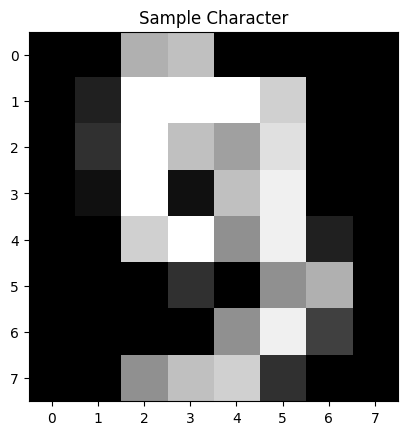

In [72]:
#svm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

digits = load_digits()

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

plt.imshow(digits.images[9], cmap='gray')
plt.title("Sample Character")
plt.show()